<a href="https://colab.research.google.com/github/AllisonHuang04/mgt151r_group38/blob/ingredients-satisfaction-eda/Ingredients_Satisfaction_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# easier way to get the dataset
path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

# Construct the full path to product_info.csv
product_info_csv_path = os.path.join(path, "product_info.csv")

#Loading product data, keep only relevant columns
product_df = pd.read_csv(product_info_csv_path)
product_df = product_df[["product_id", "product_name", "loves_count", "rating", "reviews", "ingredients", "price_usd", "highlights", "primary_category", "secondary_category", "tertiary_category"]]

product_df.info()
product_df.head()

Using Colab cache for faster access to the 'sephora-products-and-skincare-reviews' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   loves_count         8494 non-null   int64  
 3   rating              8216 non-null   float64
 4   reviews             8216 non-null   float64
 5   ingredients         7549 non-null   object 
 6   price_usd           8494 non-null   float64
 7   highlights          6287 non-null   object 
 8   primary_category    8494 non-null   object 
 9   secondary_category  8486 non-null   object 
 10  tertiary_category   7504 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 730.1+ KB


,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category
0,P473671,Fragrance Discovery Set,6320,3.6364,11.0,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets
1,P473668,La Habana Eau de Parfum,3827,4.1538,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
2,P473662,Rainbow Bar Eau de Parfum,3253,4.2500,16.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
3,P473660,Kasbah Eau de Parfum,3018,4.4762,21.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume
4,P473658,Purple Haze Eau de Parfum,2691,3.2308,13.0,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume


In [8]:
from google.colab import drive
drive.mount('/content/drive')


#Loading and concatenating all reviews datasets, keep only relevant columns
reviews1 = pd.read_csv(f"{path}/reviews_0-250.csv")
reviews2 = pd.read_csv(f"{path}/reviews_250-500.csv")
reviews3 = pd.read_csv(f"{path}/reviews_500-750.csv")
reviews4 = pd.read_csv(f"{path}/reviews_750-1250.csv")
reviews5 = pd.read_csv(f"{path}/reviews_1250-end.csv")

reviews_df = pd.concat(
    [reviews1, reviews2, reviews3, reviews4, reviews5],
    ignore_index=True
)

reviews_df = reviews_df.drop_duplicates()
reviews_df = reviews_df[["product_id", "product_name", "rating", "is_recommended", "total_feedback_count", "total_pos_feedback_count", "review_text"]]

reviews_df.info()
reviews_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-3699109381.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews1 = pd.read_csv(f"{path}/reviews_0-250.csv")
/tmp/ipython-input-3699109381.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews4 = pd.read_csv(f"{path}/reviews_750-1250.csv")
/tmp/ipython-input-3699109381.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews5 = pd.read_csv(f"{path}/reviews_1250-end.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 7 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   product_id                1094411 non-null  object 
 1   product_name              1094411 non-null  object 
 2   rating                    1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   total_feedback_count      1094411 non-null  int64  
 5   total_pos_feedback_count  1094411 non-null  int64  
 6   review_text               1092967 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 58.4+ MB


,product_id,product_name,rating,is_recommended,total_feedback_count,total_pos_feedback_count,review_text
0,P504322,Gentle Hydra-Gel Face Cleanser,5,1.0,2,2,I use this with the Nudestix “Citrus Clean Bal...
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,1,0.0,0,0,I bought this lip mask after reading the revie...
2,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,My review title says it all! I get so excited ...
3,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,I’ve always loved this formula for a long time...
4,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,5,1.0,0,0,"If you have dry cracked lips, this is a must h..."


In [10]:
#Filter for only skincare in products dataset
product_df = product_df[
    product_df["primary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["secondary_category"].str.contains("Skincare", case=False, na=False)|
    product_df["tertiary_category"].str.contains("Skincare", case=False, na=False)
]

reviews_df = reviews_df[reviews_df['product_id'].isin(product_df['product_id'])]
print(product_df.shape)
print(reviews_df.shape)

reviews_df['product_id'].value_counts()

(2522, 11)
(1094411, 7)


,count
product_id,
P420652,16138
P7880,8736
P218700,7763
P248407,7547
P269122,7414
...,...
P480441,1
P469829,1
P505174,1


In [11]:
#Check for null values
print(product_df.isna().sum())
print(reviews_df.isna().sum())

product_id              0
product_name            0
loves_count             0
rating                 73
reviews                73
ingredients           143
price_usd               0
highlights            448
primary_category        0
secondary_category      0
tertiary_category     446
dtype: int64
product_id                       0
product_name                     0
rating                           0
is_recommended              167988
total_feedback_count             0
total_pos_feedback_count         0
review_text                   1444
dtype: int64


In [12]:
#Drop null rows that may affect analysis
product_df = product_df[product_df["rating"].notna()]
product_df = product_df[product_df["ingredients"].notna()]

reviews_df = reviews_df[reviews_df["is_recommended"].notna()]

In [13]:

print("Products:", product_df.shape)
print("Unique Products:", product_df["product_id"].nunique())

print("Reviews:", reviews_df.shape)
print("Unique Reviewed Products:", reviews_df["product_id"].nunique())

Products: (2313, 11)
Unique Products: 2313
Reviews: (926423, 7)
Unique Reviewed Products: 2351


In [14]:
#Remove mini size products
product_df = product_df[~(
        product_df["primary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["secondary_category"].str.contains("Mini Size", case=False, na=False)|
        product_df["tertiary_category"].str.contains("Mini Size", case=False, na=False)
    )
]

#Update reviews dataset for removed products
reviews_df = reviews_df[reviews_df["product_id"].isin(product_df["product_id"])]

In [15]:
import re

# Standardize ingredient text
product_df["ingredients_clean"] = (
    product_df["ingredients"]
    .str.lower()
    .str.replace(r"\([^)]*\)", "", regex=True)   # remove anything in parentheses
    .str.replace(r"[^a-z, ]", "", regex=True)    # remove special characters
)

# Split into list
product_df["ingredient_list"] = product_df["ingredients_clean"].str.split(",")

# Strip whitespace
product_df["ingredient_list"] = product_df["ingredient_list"].apply(
    lambda x: [i.strip() for i in x if i.strip() != ""]
)

In [16]:
product_df

,product_id,product_name,loves_count,rating,reviews,ingredients,price_usd,highlights,primary_category,secondary_category,tertiary_category,ingredients_clean,ingredient_list
89,P439055,GENIUS Sleeping Collagen Moisturizer,33910,4.5413,1321.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Ethylh...",98.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Moisturizers,Moisturizers,"collagen , water , ethylhexyl palmitate, oryza...","[collagen, water, ethylhexyl palmitate, oryza ..."
90,P421277,GENIUS Liquid Collagen Serum,67870,4.0259,1159.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Propan...",115.0,"['Vegan', 'Good for: Loss of firmness', 'Colla...",Skincare,Treatments,Face Serums,"collagen , water , propanediol, isononyl isono...","[collagen, water, propanediol, isononyl isonon..."
91,P467602,Triple Algae Eye Renewal Balm Eye Cream,17890,4.5306,1142.0,"['Aqua (Water/Eau), Stearic Acid, Isopropyl Is...",68.0,NaN,Skincare,Eye Care,Eye Creams & Treatments,"aqua , stearic acid, isopropyl isostearate, di...","[aqua, stearic acid, isopropyl isostearate, di..."
92,P432045,GENIUS Liquid Collagen Lip Treatment,44448,3.8721,649.0,"['Collagen (Vegan)*, Water (Aqua, Eau), Glycer...",29.0,"['Vegan', 'Good for: Loss of firmness', 'Plump...",Skincare,Lip Balms & Treatments,NaN,"collagen , water , glycerin, isononyl isononan...","[collagen, water, glycerin, isononyl isononano..."
93,P311143,SUBLIME DEFENSE Ultra Lightweight UV Defense F...,27278,4.4134,508.0,"['Octinoxate 7.5%, Titanium Dioxide 2%, Zinc O...",28.0,"['Vegan', 'Hypoallergenic', 'UV Protection', '...",Skincare,Sunscreen,Face Sunscreen,"octinoxate , titanium dioxide , zinc oxide , c...","[octinoxate, titanium dioxide, zinc oxide, cyc..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8424,P501474,The Youth Vault: 13-Piece Vegan Skincare + App...,8989,4.8750,8.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",340.0,"['Clean at Sephora', 'Hydrating', 'Good for: A...",Skincare,Value & Gift Sets,NaN,"superfood antioxidant cleanser, wateraquaeau, ...","[superfood antioxidant cleanser, wateraquaeau,..."
8425,P502998,"Youth Stacks: Plump It Up for Dry, Dehydrated ...",10406,4.1667,6.0,"['Triple Peptide + Cactus Oasis Serum:', 'Wate...",28.0,"['Vegan', 'Hyaluronic Acid', 'Clean at Sephora...",Skincare,Value & Gift Sets,NaN,"triple peptide cactus oasis serum, wateraquae...","[triple peptide cactus oasis serum, wateraqua..."
8426,P503872,Mini Mandelic Acid + Superfood Unity Exfoliant,6510,4.8000,5.0,"['Water/Aqua/Eau (Aqua), Helianthus Annuus (Su...",16.0,"['Clean + Planet Positive', 'Good for: Pores',...",Skincare,Cleansers,Toners,"wateraquaeau , helianthus annuus seed oil, st...","[wateraquaeau, helianthus annuus seed oil, st..."
8427,P502977,Youth Stacks: Daily Skin Health Your Way for P...,13592,4.2500,4.0,"['Superfood Antioxidant Cleanser:', 'Water/Aqu...",20.0,"['Vegan', 'Good for: Pores', 'Clean + Planet P...",Skincare,Value & Gift Sets,NaN,"superfood antioxidant cleanser, wateraquaeau, ...","[superfood antioxidant cleanser, wateraquaeau,..."


In [17]:
from collections import Counter

# Flatten ingredient lists
all_ingredients = [
    ingredient
    for sublist in product_df["ingredient_list"]
    for ingredient in sublist
]

ingredient_counts = Counter(all_ingredients)

ingredient_freq_df = pd.DataFrame(
    ingredient_counts.items(),
    columns=["ingredient", "count"]
).sort_values(by="count", ascending=False)

ingredient_freq_df.head(20)

,ingredient,count
5,glycerin,1935
33,phenoxyethanol,1356
44,butylene glycol,1129
20,tocopherol,1029
27,citric acid,981
25,ethylhexylglycerin,900
81,sodium hyaluronate,895
42,propanediol,888
186,xanthan gum,862
1,water,849


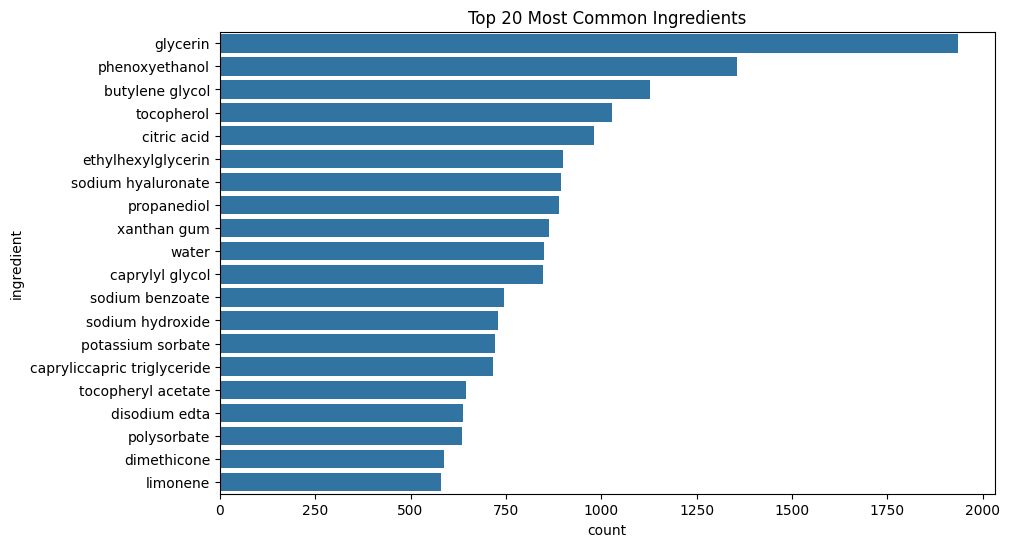

In [18]:
top20 = ingredient_freq_df.head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=top20, x="count", y="ingredient")
plt.title("Top 20 Most Common Ingredients")
plt.show()

In [19]:
top_ingredients = ingredient_freq_df.head(30)["ingredient"].tolist()

for ingredient in top_ingredients:
    product_df[ingredient] = product_df["ingredient_list"].apply(
        lambda x: 1 if ingredient in x else 0
    )

In [20]:
ingredient_lift_results = []

for ingredient in top_ingredients:
    present = product_df[product_df[ingredient] == 1]["rating"]
    absent = product_df[product_df[ingredient] == 0]["rating"]

    lift = present.mean() - absent.mean()

    ingredient_lift_results.append({
        "ingredient": ingredient,
        "avg_rating_present": present.mean(),
        "avg_rating_absent": absent.mean(),
        "lift": lift,
        "count_present": present.count()
    })

ingredient_lift_df = pd.DataFrame(ingredient_lift_results)
ingredient_lift_df = ingredient_lift_df.sort_values(by="lift", ascending=False)

ingredient_lift_df.head(10)

,ingredient,avg_rating_present,avg_rating_absent,lift,count_present
23,hexanediol,4.307248,4.223411,0.083838,464
28,helianthus annuus seed oil,4.291859,4.231699,0.060159,350
22,wateraquaeau,4.288877,4.228919,0.059958,451
19,limonene,4.286499,4.227648,0.058851,506
3,tocopherol,4.274945,4.216366,0.058579,923
12,sodium hydroxide,4.264381,4.231421,0.032960,657
21,squalane,4.264991,4.234124,0.030867,513
4,citric acid,4.256005,4.231184,0.024821,893
20,linalool,4.259545,4.236170,0.023375,489
27,cetearyl alcohol,4.260165,4.236870,0.023295,426


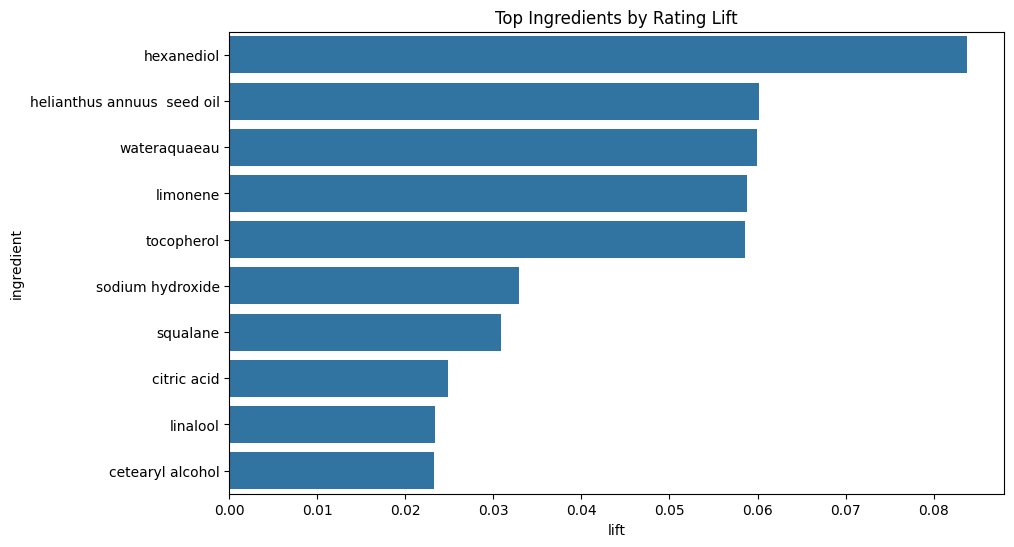

In [21]:
top_lift = ingredient_lift_df.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_lift, x="lift", y="ingredient")
plt.title("Top Ingredients by Rating Lift")
plt.show()

In [22]:
ingredient_lift_df = ingredient_lift_df[ingredient_lift_df["count_present"] > 20]